# 04  Backtest & Strategy Comparison
 
Aggregates the per-fold predictions saved by `scripts/03bis_walk_forward.py` into a continuous out-of-sample track record, computes the paper's full performance table, and benchmarks the DMN variants against simple references.
 
**Variants compared:**
- DMN (LSTM only)
- DMN + CPD
- DMN long-only + CPD
- **DMN long-only + CPD + 25 bps cost-aware loss**
- MACD
- TSMOM (Moskowitz)
- EW-SXXR (`long_only`), "does the learned LSTM signal add value over the trivial signal $X_t=1$, within the same vol-scaling framework?"
- SXXR, "does the active model beat passive buy-and-hold?"
 
 **Metrics used:** annualised return, vol, Sharpe; downside deviation and Sortino; max drawdown and Calmar; hit rate; profit/loss ratio. Reported both raw and rescaled to 15% vol target.

In [36]:
from pathlib import Path
import sys, warnings, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100, "axes.grid": True})

## Configuration

In [37]:
with open(PROJECT_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

PROCESSED_DIR = PROJECT_ROOT / cfg["data"]["processed_dir"]
MODELS_DIR    = PROJECT_ROOT / cfg["data"]["processed_mod"]
TARGET_VOL    = cfg["vol_target"]
CPD_LBW       = cfg["dmn"]["cpd_lbw"]
CPD_STRIDE    = cfg["dmn"].get("cpd_stride", 1)
FOLD_TYPE     = cfg.get("fold_type", "expanding")
#FOLD_TYPE = "rolling"  # uncomment to use it for sensitivity analysis

# Transaction cost applied at backtest time to all variants
TRANSACTION_COST = 0.0025

print(f"Models dir:        {MODELS_DIR}")
print(f"Target vol:        {TARGET_VOL:.0%}")
print(f"CPD setup:         lbw={CPD_LBW}, stride={CPD_STRIDE}")
print(f"Fold type:         {FOLD_TYPE}")
print(f"Transaction cost:  {TRANSACTION_COST*1e4:.0f} bps")

Models dir:        c:\Users\vonae\Documents\GitHub\Pergam_MSc_2026\data\processed\models
Target vol:        15%
CPD setup:         lbw=63, stride=1
Fold type:         expanding
Transaction cost:  25 bps


## Load DMN predictions
 
Predictions from each fold are concatenated into a single continuous out-of-sample series. We support multiple variants in parallel, the variant suffix (e.g. `cpd21_s5`, `nocpd`, `cpd21_s5_longonly`) is the discriminator. Files matching the pattern but missing on disk are skipped.

In [38]:
def load_variant(suffix: str) -> pd.DataFrame:
    """Concatenate predictions across all folds for a given DMN variant.
    
    Pattern: predictions_fold*_{suffix}.csv
    Returns empty DataFrame if no files match.
    """
    files = sorted(MODELS_DIR.glob(f"predictions_fold*_{suffix}.csv"))
    if not files:
        return pd.DataFrame()
    frames = [pd.read_csv(f, parse_dates=["date"]) for f in files]
    df = pd.concat(frames, ignore_index=True).sort_values(["date", "ticker"])
    df["variant"] = suffix
    return df

# Build the variants registry: maps a readable label to the suffix in the filename.
# Edit this to add/remove variants from the comparison.
VARIANTS = {
    "dmn_baseline":         f"{FOLD_TYPE}_nocpd",
    "dmn_cpd":              f"{FOLD_TYPE}_cpd{CPD_LBW}_s{CPD_STRIDE}",
    "dmn_cpd_longonly":     f"{FOLD_TYPE}_cpd{CPD_LBW}_s{CPD_STRIDE}_longonly",
    "dmn_cpd_longonly_tc":  f"{FOLD_TYPE}_cpd{CPD_LBW}_s{CPD_STRIDE}_longonly_tc25bps",
}

dmn_predictions = {}
for label, suffix in VARIANTS.items():
    df = load_variant(suffix)
    if df.empty:
        print(f"  {label}: no files matching predictions_fold*_{suffix}.csv — skipping")
    else:
        dmn_predictions[label] = df
        print(f"  {label}: {len(df):,} rows, "
              f"{df['date'].min().date()}/{df['date'].max().date()}")

if not dmn_predictions:
    raise FileNotFoundError("No DMN predictions found. Run scripts/03bis_walk_forward.py first.")

  dmn_baseline: 481,086 rows, 2011-01-03/2025-12-31
  dmn_cpd: 393,308 rows, 2011-01-03/2025-12-30
  dmn_cpd_longonly: 393,308 rows, 2011-01-03/2025-12-30
  dmn_cpd_longonly_tc: 393,308 rows, 2011-01-03/2025-12-30


## Load benchmarks and the processed panel
 
We need the panel to compute the classical TSMOM and MACD reference signals on the same dates as the DMN test predictions, ensuring a fair comparison.

In [39]:
benchmarks = pd.read_csv(PROCESSED_DIR / "benchmark_stoxx600_ew.csv", parse_dates=["date"])
print(f"Benchmarks: {len(benchmarks):,} rows, {benchmarks['benchmark'].unique().tolist()}")

stocks = pd.read_csv(
    PROCESSED_DIR / "stoxx600_processed.csv",
    parse_dates=["date"],
    usecols=["date", "ticker", "1d_arith_ret", "60d_ewm_vol", "252d_arith_ret", "macd_8_24", "macd_16_48", "macd_32_96"])

oos_start = min(df["date"].min() for df in dmn_predictions.values())
oos_end = max(df["date"].max() for df in dmn_predictions.values())
stocks_oos = stocks.loc[(stocks["date"] >= oos_start) & (stocks["date"] <= oos_end)].copy()
print(f"Out-of-sample period: {oos_start.date()}/{oos_end.date()} "
      f"({stocks_oos['date'].nunique():,} days, {stocks_oos['ticker'].nunique():,} tickers)")

Benchmarks: 10,528 rows, ['SXXR', 'EW']
Out-of-sample period: 2011-01-03/2025-12-31 (3,913 days, 1,103 tickers)


## Build paper's reference strategies
 
These are computed on the same panel and dates as the DMN predictions to ensure a fair side-by-side comparison.

- **Long-only**: $X_t = 1$ for every stock (= EW-SXXR portfolio).
- **Moskowitz (2012)**: $X_t = (1-w)\mathrm{sgn}(r_{t-252,t})+w \mathrm{sgn}(r_{t-21,t})$, with $w=0$. This strategy purely exploits long-term trends by considering a 12-month lbw to determine the position sizing, ignoring the short-term signal component $ \mathrm{sgn}(r_{t-21,t})$. The $\mathrm{sgn}$ function maps the return into a full long ($+1$) or full short ($-1$) position.
- **MACD**: $\mathrm{sgn}$ of the average of three vol-normalised MACD signals.

In [40]:
def vol_scaled_strategy_return(positions, ret_real, ex_ante_vol, target_vol=TARGET_VOL):
    """Apply paper Eq. 11 vol scaling to per-(stock, date) positions."""
    return positions * (target_vol / np.maximum(ex_ante_vol, 1e-6)) * ret_real

stocks_oos["pos_long_only"] = 1.0
stocks_oos["pos_moskowitz"] = np.sign(stocks_oos["252d_arith_ret"].fillna(0.0))

macd_signal = stocks_oos[["macd_8_24", "macd_16_48", "macd_32_96"]].mean(axis=1)
stocks_oos["pos_macd"] = np.sign(macd_signal.fillna(0.0))

# Correct per-ticker next-day return
stocks_oos = stocks_oos.sort_values(["ticker", "date"])
stocks_oos["next_day_ret"] = stocks_oos.groupby("ticker")["1d_arith_ret"].shift(-1)

# Remove year-boundary artifacts (multi-year returns labeled as daily)
next_date = stocks_oos.groupby("ticker")["date"].shift(-1)
gap_days = (next_date - stocks_oos["date"]).dt.days
stocks_oos.loc[gap_days > 5, "next_day_ret"] = np.nan

for name in ["long_only", "moskowitz", "macd"]:
    stocks_oos[f"strat_{name}_gross"] = vol_scaled_strategy_return(
        stocks_oos[f"pos_{name}"],
        stocks_oos["next_day_ret"],
        stocks_oos["60d_ewm_vol"],
    )

classical_cols = ["date", "ticker", "60d_ewm_vol"] + \
                 [f"pos_{n}" for n in ["long_only", "moskowitz", "macd"]] + \
                 [f"strat_{n}_gross" for n in ["long_only", "moskowitz", "macd"]]
classical = (stocks_oos[classical_cols]
              .dropna(subset=[f"strat_{n}_gross" for n in ["long_only", "moskowitz", "macd"]])
              .reset_index(drop=True))
print(f"Classical strategies computed on {len(classical):,} (stock, date) pairs")

Classical strategies computed on 2,163,790 (stock, date) pairs


## Apply transaction costs (paper Eq. C1)
 
The cost is proportional to the change in the vol-scaled position $X_t / \sigma_t$ between consecutive periods. We apply this at the backtest layer to all variants uniformly, even those already trained with cost-aware loss, so the comparison is fair (every strategy bears the same realised transaction cost).

For the DMN variants, the file already contains `strat_ret_gross` and `strat_ret` columns (net of training-time costs if applicable). Here we recompute net returns at the backtest cost level, overwriting `strat_ret`.

In [41]:
def add_transaction_costs(df: pd.DataFrame, position_col: str, vol_col: str,
                          gross_col: str, net_col: str,
                          cost: float = TRANSACTION_COST,
                          target_vol: float = TARGET_VOL) -> pd.DataFrame:
    """Subtract cost * target_vol * |Δ(X / sigma)| from the gross strategy return.
    
    Per-ticker turnover; output written to `net_col`.
    """
    df = df.sort_values(["ticker", "date"]).copy()
    df["_scaled_pos"]   = df[position_col] / np.maximum(df[vol_col], 1e-6)
    df["_d_scaled_pos"] = df.groupby("ticker")["_scaled_pos"].diff().fillna(0.0)
    df[net_col] = df[gross_col] - cost * target_vol * df["_d_scaled_pos"].abs()
    return df.drop(columns=["_scaled_pos", "_d_scaled_pos"])
# the cost is charged every day on which the position in a stock changed, proportional to how much it changed.

# DMN variants: recompute net returns at backtest cost level
# (overwrites the strat_ret column from the predictions file)
for label, df in dmn_predictions.items():
    if "strat_ret_gross" not in df.columns:
        # Backward compat: old prediction files only have strat_ret
        df["strat_ret_gross"] = df["strat_ret"].copy()
    dmn_predictions[label] = add_transaction_costs(
        df, position_col="position", vol_col="ex_ante_vol",
        gross_col="strat_ret_gross", net_col="strat_ret"
    )

# Classical strategies
for name in ["long_only", "moskowitz", "macd"]:
    classical = add_transaction_costs(
        classical, position_col=f"pos_{name}", vol_col="60d_ewm_vol",
        gross_col=f"strat_{name}_gross", net_col=f"strat_{name}"
    )

## Aggregate to portfolio level
 
Equal-weighted across stocks at each date. This matches the paper's convention (the strategy is defined per asset, then averaged).

In [42]:
def to_portfolio_series(df: pd.DataFrame, strat_col: str) -> pd.Series:
    return df.groupby("date")[strat_col].mean().sort_index()

portfolios = {}

# DMN variants: gross + net
for label, df in dmn_predictions.items():
    portfolios[f"{label}_gross"] = to_portfolio_series(df, "strat_ret_gross")
    portfolios[f"{label}_net"]   = to_portfolio_series(df, "strat_ret")

# Classical strategies: gross + net
for name in ["long_only", "moskowitz", "macd"]:
    portfolios[f"{name}_gross"] = to_portfolio_series(classical, f"strat_{name}_gross")
    portfolios[f"{name}_net"]   = to_portfolio_series(classical, f"strat_{name}")

# SXXR (cap-weighted reference), no cost adjustment, it's an index level
sxxr_prices  = (benchmarks.loc[benchmarks["benchmark"] == "SXXR"]
                           .set_index("date")["price"].sort_index())
portfolios["sxxr"] = (sxxr_prices.pct_change()
                                  .loc[(sxxr_prices.index >= oos_start) &
                                       (sxxr_prices.index <= oos_end)])

print(f"Portfolios computed: {len(portfolios)} series")

Portfolios computed: 15 series


## Performance metrics
 
Replicates paper Exhibit 3. All metrics annualised, returns compound daily, drawdowns continuous from peak.

In [43]:
def compute_metrics(returns: pd.Series) -> dict:
    """Standard performance metrics for a daily strategy return series."""
    r = returns.dropna()
    if len(r) < 2:
        return {k: np.nan for k in [
            "Returns", "Vol", "Sharpe", "Downside Dev", "Sortino",
            "MDD", "Calmar", "% +ve", "Avg P / Avg L"
        ]}
    
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    
    downside = r[r < 0]
    dd_dev   = downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan
    sortino  = ann_ret / dd_dev if dd_dev > 0 else np.nan
    
    cum = (1 + r).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    mdd = dd.min()
    calmar = ann_ret / abs(mdd) if mdd != 0 else np.nan
    
    pct_pos = (r > 0).mean()
    avg_p   = r[r > 0].mean()
    avg_l   = abs(r[r < 0].mean())
    p_to_l  = avg_p / avg_l if avg_l > 0 else np.nan
    
    return {
        "Returns": ann_ret, "Vol": ann_vol, "Sharpe": sharpe,
        "Downside Dev": dd_dev, "Sortino": sortino,
        "MDD": mdd, "Calmar": calmar,
        "% +ve": pct_pos, "Avg P / Avg L": p_to_l,
    }

def format_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Pretty-print formatting for the metrics table."""
    fmt = df.copy()
    for col in ["Returns", "Vol", "Downside Dev", "MDD"]:
        if col in fmt.columns:
            fmt[col] = fmt[col].map(lambda x: f"{x:+.2%}" if pd.notna(x) else "—")
    for col in ["Sharpe", "Sortino", "Calmar", "Avg P / Avg L"]:
        if col in fmt.columns:
            fmt[col] = fmt[col].map(lambda x: f"{x:+.3f}" if pd.notna(x) else "—")
    if "% +ve" in fmt.columns:
        fmt["% +ve"] = fmt["% +ve"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
    return fmt

# Master metrics table
metric_rows = []
for label, ret_series in portfolios.items():
    m = compute_metrics(ret_series)
    m["Strategy"] = label
    metric_rows.append(m)

metrics_df = (pd.DataFrame(metric_rows).set_index("Strategy")
              [["Returns", "Vol", "Sharpe", "Downside Dev",
                "Sortino", "MDD", "Calmar", "% +ve", "Avg P / Avg L"]])

print(f"\nFull-period out-of-sample metrics:")
print(f"({TRANSACTION_COST*1e4:.0f} bps backtest-time costs applied to all variants)\n")
print(format_metrics(metrics_df).to_string())


Full-period out-of-sample metrics:
(25 bps backtest-time costs applied to all variants)

                          Returns      Vol  Sharpe Downside Dev Sortino      MDD  Calmar  % +ve Avg P / Avg L
Strategy                                                                                                     
dmn_baseline_gross         +0.53%   +1.07%  +0.495       +0.90%  +0.590   -3.58%  +0.149  52.1%        +1.017
dmn_baseline_net           -1.13%   +1.08%  -1.048       +0.86%  -1.312  -13.57%  -0.083  43.1%        +1.063
dmn_cpd_gross              +0.53%   +0.77%  +0.680       +0.68%  +0.778   -2.27%  +0.231  52.5%        +1.060
dmn_cpd_net                -1.46%   +0.78%  -1.883       +0.64%  -2.274  -13.71%  -0.107  38.4%        +1.045
dmn_cpd_longonly_gross     +0.92%   +1.69%  +0.545       +1.49%  +0.622   -4.30%  +0.215  54.3%        +0.952
dmn_cpd_longonly_net       -0.25%   +1.70%  -0.146       +1.47%  -0.168   -4.89%  -0.051  50.4%        +0.951
dmn_cpd_longonly_tc_gross  +1.

We trained only one model specifically to be cost-aware (suffix `_tc`), but the backtest then charges costs to everyone equally.


| | **gross (no cost charged)** | **net (25 bps charged)** |
| :--- | :--- | :--- |
| **trained without cost term** | `dmn_cpd_longonly_gross` | ``dmn_cpd_longonly_net`` |
| **trained with cost term** | `dmn_cpd_longonly_tc_gross` | ``dmn_cpd_longonly_tc_net`` |

## Vol-rescaled metrics (paper Exhibit 4)
 
Each strategy rescaled to 15% annualised vol so risk-adjusted comparison is direct (all strategies have the same vol).

In [44]:
def rescale_to_target_vol(returns: pd.Series, target_vol=TARGET_VOL) -> pd.Series:
    r = returns.dropna()
    if len(r) < 2: return r
    realised_vol = r.std() * np.sqrt(252)
    if realised_vol == 0: return r
    return r * (target_vol / realised_vol)

rescaled = {label: rescale_to_target_vol(s) for label, s in portfolios.items()}

rescaled_metric_rows = []
for label, ret_series in rescaled.items():
    m = compute_metrics(ret_series)
    m["Strategy"] = label
    rescaled_metric_rows.append(m)

rescaled_metrics_df = (pd.DataFrame(rescaled_metric_rows).set_index("Strategy")
                       [["Returns", "Vol", "Sharpe", "Downside Dev",
                         "Sortino", "MDD", "Calmar", "% +ve", "Avg P / Avg L"]])

print(f"\nVol-rescaled metrics (paper Exhibit 4 format, all at {TARGET_VOL:.0%} vol):\n")
print(format_metrics(rescaled_metrics_df).to_string())


Vol-rescaled metrics (paper Exhibit 4 format, all at 15% vol):

                           Returns      Vol  Sharpe Downside Dev Sortino      MDD  Calmar  % +ve Avg P / Avg L
Strategy                                                                                                      
dmn_baseline_gross          +7.42%  +15.00%  +0.495      +12.59%  +0.590  -41.89%  +0.177  52.1%        +1.017
dmn_baseline_net           -15.72%  +15.00%  -1.048      +11.98%  -1.312  -88.35%  -0.178  43.1%        +1.063
dmn_cpd_gross              +10.19%  +15.00%  +0.680      +13.11%  +0.778  -37.28%  +0.273  52.5%        +1.060
dmn_cpd_net                -28.25%  +15.00%  -1.883      +12.42%  -2.274  -94.78%  -0.298  38.4%        +1.045
dmn_cpd_longonly_gross      +8.18%  +15.00%  +0.545      +13.16%  +0.622  -33.22%  +0.246  54.3%        +0.952
dmn_cpd_longonly_net        -2.19%  +15.00%  -0.146      +13.03%  -0.168  -38.41%  -0.057  50.4%        +0.951
dmn_cpd_longonly_tc_gross   +7.50%  +15.00%  +0

## Equity curves
 
Top: raw signal output. Bottom: vol-rescaled to 15% (directly comparable on a risk-adjusted basis).

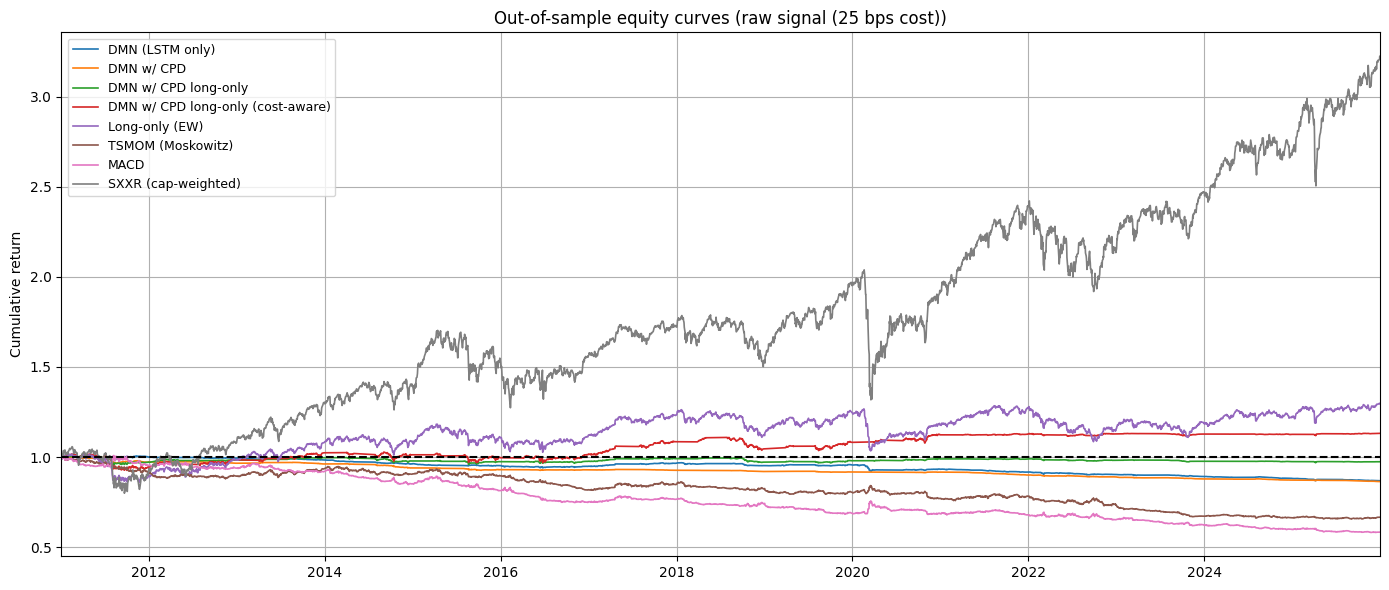

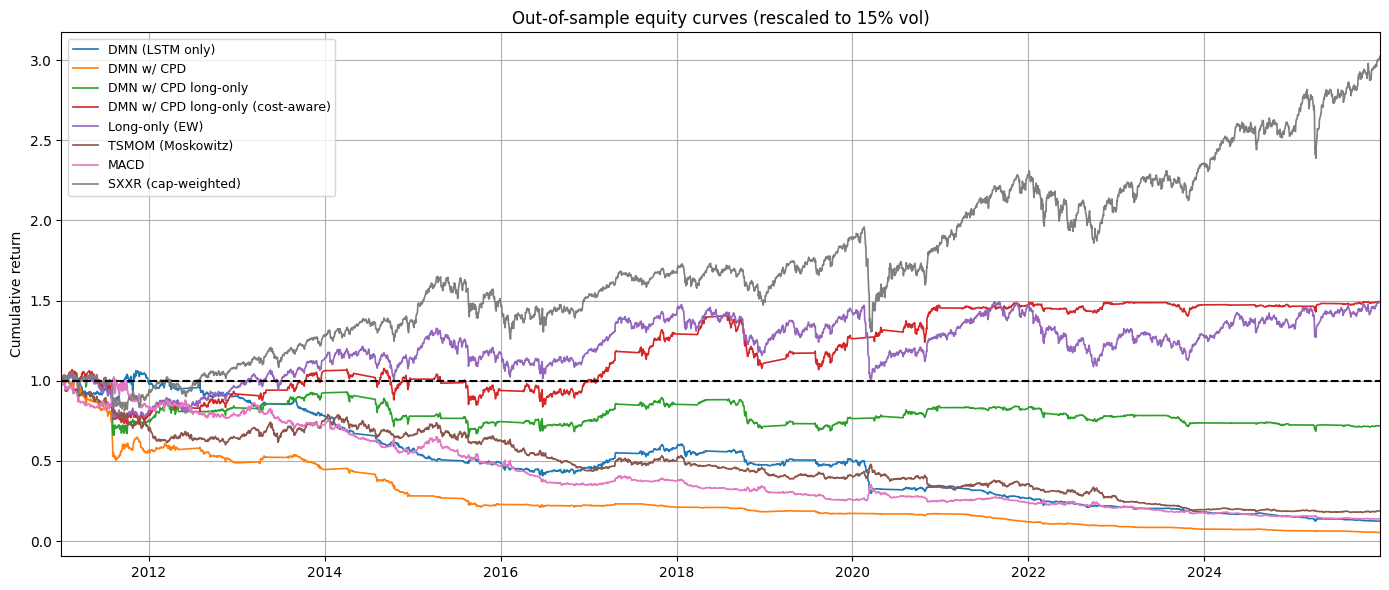

In [45]:
LABELS = {
    "dmn_baseline_net":           "DMN (LSTM only)",
    "dmn_cpd_net":                "DMN w/ CPD",
    "dmn_cpd_longonly_net":       "DMN w/ CPD long-only",
    "dmn_cpd_longonly_tc_net":    "DMN w/ CPD long-only (cost-aware)",
    "long_only_net":              "Long-only (EW)",
    "moskowitz_net":              "TSMOM (Moskowitz)",
    "macd_net":                   "MACD",
    "sxxr":                       "SXXR (cap-weighted)",
}

def set_xlim_to_plotted_data(ax):
    lines = ax.get_lines()
    if not lines:
        return
    all_xdata = []
    for line in lines:
        all_xdata.extend(line.get_xdata())
    if all_xdata:
        valid_dates = [x for x in all_xdata if pd.notna(x)]
        if valid_dates:
            ax.set_xlim(min(valid_dates), max(valid_dates))

def plot_equity_curves(portfolios_dict, title_suffix, labels, log=False):
    fig, ax = plt.subplots(figsize=(14, 6))
    for label, ret in portfolios_dict.items():
        if label not in labels:
            continue
        cum = (1 + ret.dropna()).cumprod()
        ax.plot(cum.index, cum.values, lw=1.2, label=labels[label])
    
    set_xlim_to_plotted_data(ax)
    ax.axhline(1.0, color="black", lw=1.5, linestyle="--")
    
    if log:
        ax.set_yscale("log")
    ax.set_title(f"Out-of-sample equity curves ({title_suffix})")
    ax.set_ylabel("Cumulative return" + (" (log)" if log else ""))
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_equity_curves(portfolios, f"raw signal ({TRANSACTION_COST*1e4:.0f} bps cost)", LABELS, log=False)
plot_equity_curves(rescaled, f"rescaled to {TARGET_VOL:.0%} vol", LABELS, log=False)

## Drawdown Analysis

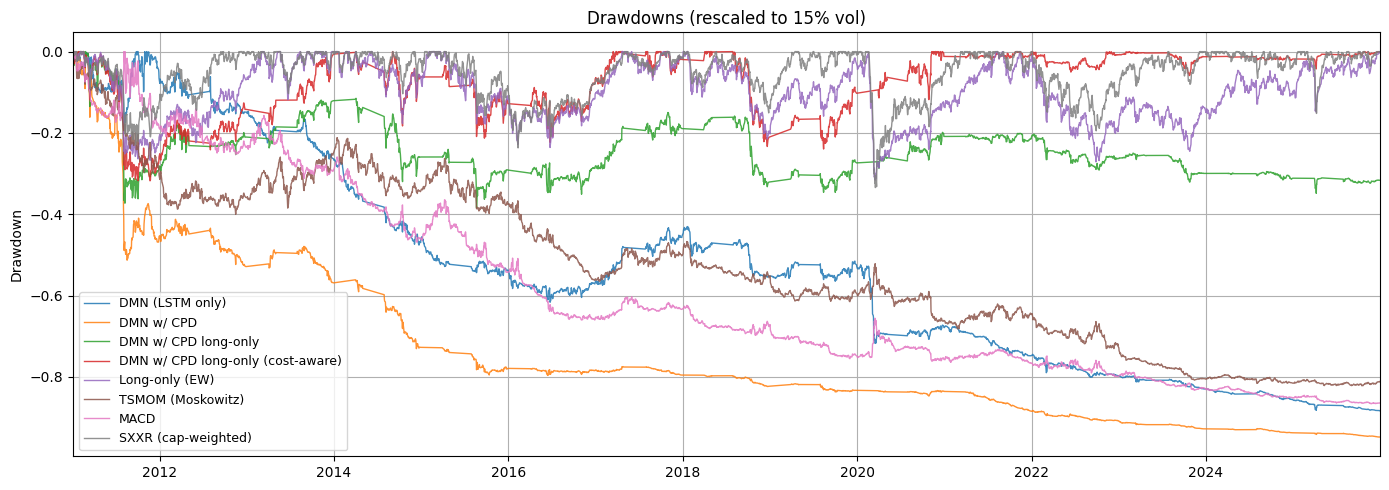

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))
for label, ret in rescaled.items():
    if label not in LABELS:
        continue
    cum = (1 + ret.dropna()).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    ax.plot(dd.index, dd.values, lw=1.0, label=LABELS[label], alpha=0.85)

set_xlim_to_plotted_data(ax)
ax.set_title(f"Drawdowns (rescaled to {TARGET_VOL:.0%} vol)")
ax.set_ylabel("Drawdown")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

## Rolling Sharpe ratio
 
Trailing 252-day Sharpe assesses regime-dependence and the CPD module's value-add over time.


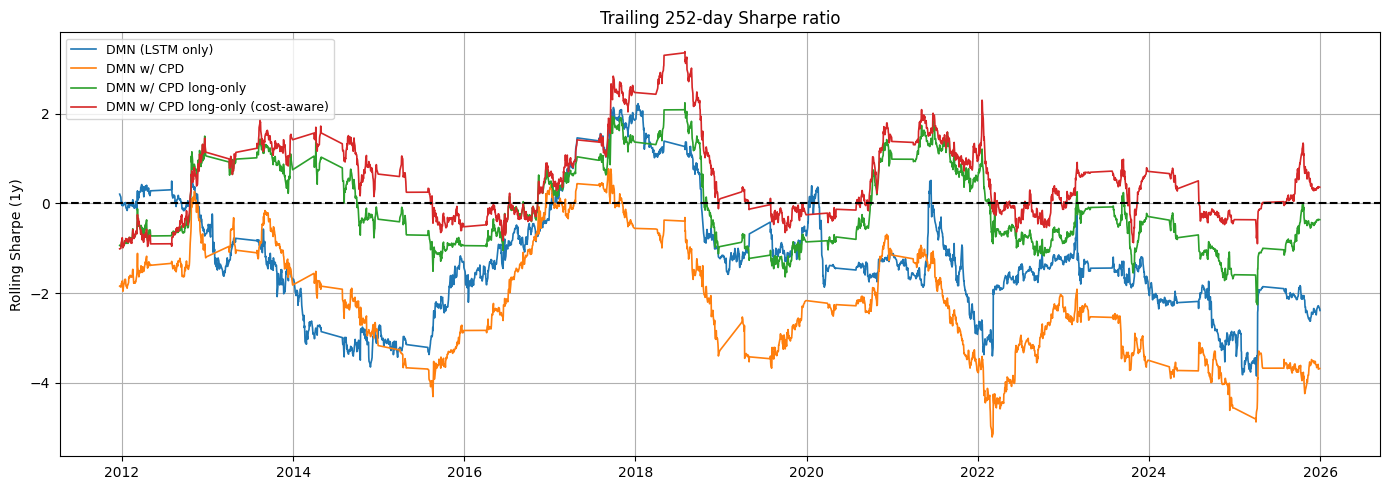

In [47]:
def rolling_sharpe(returns: pd.Series, window: int = 252) -> pd.Series:
    r = returns.dropna()
    return (r.rolling(window).mean() / r.rolling(window).std()) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
for label in ["dmn_baseline_net", "dmn_cpd_net",
               "dmn_cpd_longonly_net", "dmn_cpd_longonly_tc_net"]:
    if label not in portfolios:
        continue
    rs = rolling_sharpe(portfolios[label])
    ax.plot(rs.index, rs.values, lw=1.2, label=LABELS[label])
ax.axhline(0, color="black", lw=1.5, linestyle="--")
ax.set_title("Trailing 252-day Sharpe ratio")
ax.set_ylabel("Rolling Sharpe (1y)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Sharpe by year
 
Cross-year breakdown for regime-dependence analysis. The paper notes the CPD module is especially valuable in 2015-2020.

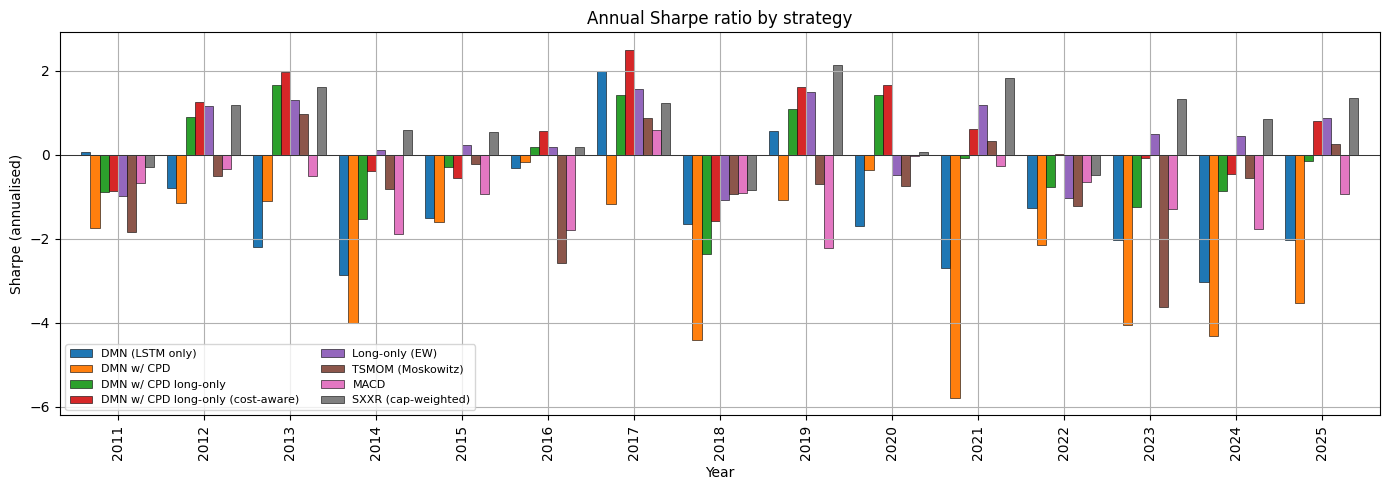


Sharpe by year:
      DMN (LSTM only)  DMN w/ CPD  DMN w/ CPD long-only  DMN w/ CPD long-only (cost-aware)  Long-only (EW)  TSMOM (Moskowitz)  MACD  SXXR (cap-weighted)
date                                                                                                                                                    
2011             0.05       -1.74                 -0.88                              -0.87           -0.98              -1.85 -0.66                -0.29
2012            -0.80       -1.14                  0.90                               1.26            1.15              -0.50 -0.34                 1.18
2013            -2.21       -1.11                  1.65                               1.98            1.30               0.97 -0.52                 1.60
2014            -2.87       -4.01                 -1.54                              -0.39            0.12              -0.81 -1.90                 0.58
2015            -1.51       -1.61                 -0.30          

In [54]:
def yearly_sharpe(returns: pd.Series) -> pd.Series:
    r = returns.dropna()
    return r.groupby(r.index.year).apply(
        lambda y: (y.mean() / y.std()) * np.sqrt(252) if y.std() > 0 else 0.0
    )

# Build the yearly table for strategies we want to compare
yearly_table = pd.DataFrame({
    LABELS[label]: yearly_sharpe(portfolios[label])
    for label in LABELS if label in portfolios
})

fig, ax = plt.subplots(figsize=(14, 5))
yearly_table.plot(kind="bar", ax=ax,width=0.85, edgecolor="black", linewidth=0.4,)
ax.set_title("Annual Sharpe ratio by strategy")
ax.set_ylabel("Sharpe (annualised)"); ax.set_xlabel("Year")
ax.axhline(0, color="black", lw=0.5)
ax.legend(fontsize=8, ncol=2, loc="lower left")
plt.tight_layout()
plt.show()

print(f"\nSharpe by year:")
print(yearly_table.round(2).to_string())

## Transaction cost sensitivity (paper Exhibit 8)
 
How does Sharpe degrade as we increase per-transaction cost from 0 bps to 50 bps? The paper notes DMNs deteriorate quickly above ~2 bps without a cost-aware loss; with a cost-aware model (our `dmn_cpd_longonly_tc` variant), we expect more graceful degradation.

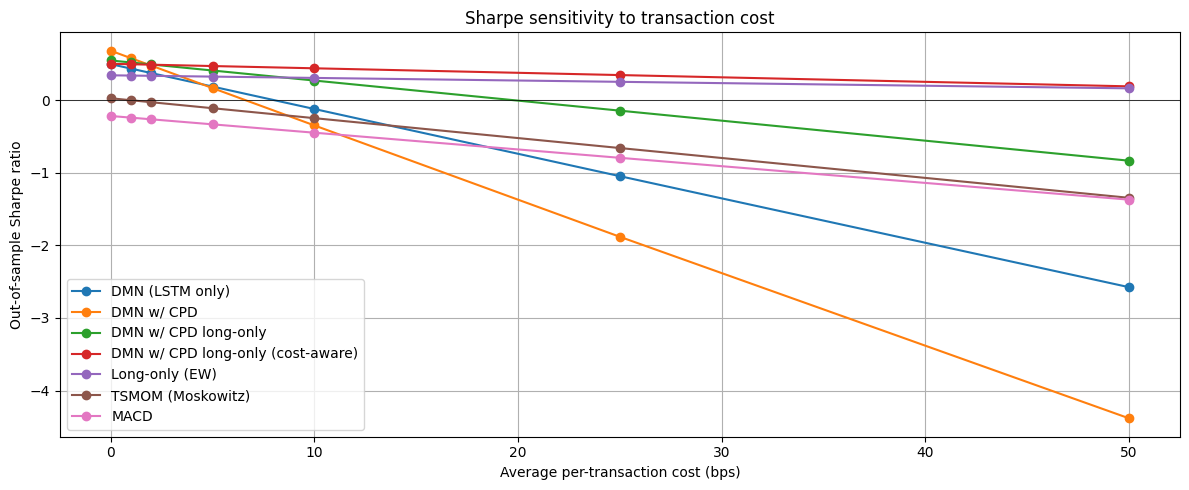


Sharpe at each cost level:
            dmn_baseline  dmn_cpd  dmn_cpd_longonly  dmn_cpd_longonly_tc  long_only  moskowitz   macd
Cost (bps)                                                                                           
0                  0.495    0.680             0.545                0.500      0.341      0.025 -0.219
1                  0.433    0.577             0.518                0.493      0.337     -0.002 -0.242
2                  0.371    0.474             0.490                0.487      0.334     -0.030 -0.265
5                  0.186    0.165             0.407                0.469      0.323     -0.112 -0.334
10                -0.123   -0.349             0.269                0.438      0.305     -0.249 -0.450
25                -1.048   -1.883            -0.146                0.344      0.251     -0.661 -0.795
50                -2.577   -4.383            -0.835                0.189      0.161     -1.346 -1.372


In [50]:
COST_GRID_BPS = [0, 1, 2, 5, 10, 25, 50]
COST_GRID = [c * 1e-4 for c in COST_GRID_BPS]

def sharpe_at_cost(df: pd.DataFrame, cost: float, position_col="position",
                    vol_col="ex_ante_vol", gross_col="strat_ret_gross") -> float:
    """Re-derive Sharpe after subtracting per-ticker turnover cost."""
    adj = add_transaction_costs(
        df, position_col=position_col, vol_col=vol_col,
        gross_col=gross_col, net_col="_tmp_net", cost=cost
    )
    port = to_portfolio_series(adj, "_tmp_net")
    return compute_metrics(port).get("Sharpe", np.nan)

cost_sens = {}
for label, df in dmn_predictions.items():
    cost_sens[label] = [sharpe_at_cost(df, c) for c in COST_GRID]

for name in ["long_only", "moskowitz", "macd"]:
    sharpes = []
    for c in COST_GRID:
        sharpes.append(sharpe_at_cost(
            classical, c,
            position_col=f"pos_{name}", vol_col="60d_ewm_vol",
            gross_col=f"strat_{name}_gross"
        ))
    cost_sens[name] = sharpes

cost_table = pd.DataFrame(cost_sens, index=COST_GRID_BPS)
cost_table.index.name = "Cost (bps)"

fig, ax = plt.subplots(figsize=(12, 5))
for label in cost_table.columns:
    # Try to get a readable label; fall back to the raw column name
    display_label = LABELS.get(label + "_net", LABELS.get(label, label))
    ax.plot(cost_table.index, cost_table[label], marker="o", lw=1.5,
             label=display_label)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Average per-transaction cost (bps)"); ax.set_ylabel("Out-of-sample Sharpe ratio")
ax.set_title("Sharpe sensitivity to transaction cost")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

print(f"\nSharpe at each cost level:")
print(cost_table.round(3).to_string())

In [51]:
print("Unique tickers per year in OOS panel:")
print(stocks_oos.groupby(stocks_oos["date"].dt.year)["ticker"].nunique())
# They should be exactly 600 

Unique tickers per year in OOS panel:
date
2011    600
2012    600
2013    600
2014    600
2015    600
2016    600
2017    599
2018    599
2019    599
2020    599
2021    599
2022    600
2023    600
2024    600
2025    600
Name: ticker, dtype: int64


## CPD lookback window sensitivity 

Compares the long-only DMN trained with CPD at two different lookback windows: `lbw`=21 (paper default, monthly regime detection) vs `lbw`=63 (quarterly regime detection). Both use the same stride and fold type.

LBW=21: 396,402 rows, 2011-01-03 2025-12-30
LBW=63: 393,308 rows, 2011-01-03 2025-12-30


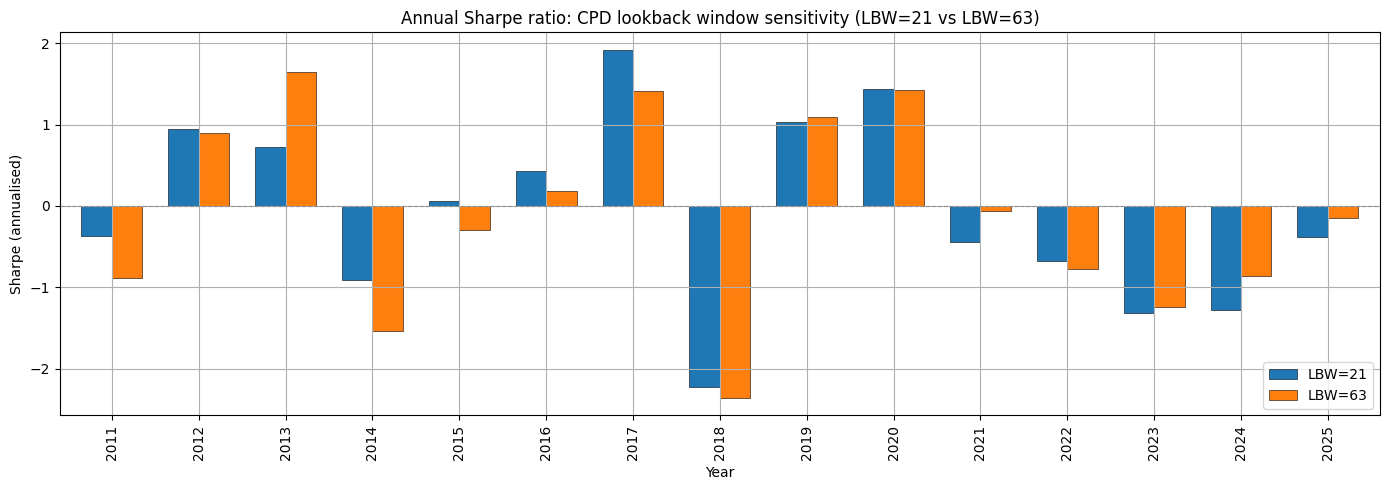

      LBW=21  LBW=63
date                
2011   -0.37   -0.88
2012    0.94    0.90
2013    0.72    1.65
2014   -0.92   -1.54
2015    0.06   -0.30
2016    0.43    0.18
2017    1.92    1.41
2018   -2.23   -2.36
2019    1.03    1.09
2020    1.43    1.43
2021   -0.45   -0.07
2022   -0.68   -0.77
2023   -1.32   -1.24
2024   -1.28   -0.86
2025   -0.38   -0.15


In [59]:
# Load predictions for both LBW variants
lbw_variants = {
    "LBW=21": f"{FOLD_TYPE}_cpd21_s{CPD_STRIDE}_longonly",
    "LBW=63": f"{FOLD_TYPE}_cpd63_s{CPD_STRIDE}_longonly",
}

lbw_predictions = {}
for label, suffix in lbw_variants.items():
    df = load_variant(suffix)
    if df.empty:
        print(f"  {label}: no files matching predictions_fold*_{suffix}.csv — skipping")
        continue
    if "strat_ret_gross" not in df.columns:
        df["strat_ret_gross"] = df["strat_ret"].copy()
    lbw_predictions[label] = add_transaction_costs(
        df, position_col="position", vol_col="ex_ante_vol",
        gross_col="strat_ret_gross", net_col="strat_ret"
    )
    print(f"{label}: {len(df):,} rows, {df['date'].min().date()} {df['date'].max().date()}")

if not lbw_predictions:
    raise FileNotFoundError("No LBW comparison predictions found.")

# Build portfolio series (net of costs) for each LBW
lbw_portfolios = {
    label: to_portfolio_series(df, "strat_ret")
    for label, df in lbw_predictions.items()
}

# Compute yearly Sharpe for each
lbw_yearly_table = pd.DataFrame({
    label: yearly_sharpe(port)
    for label, port in lbw_portfolios.items()
})

fig, ax = plt.subplots(figsize=(14, 5))
lbw_yearly_table.plot(kind="bar", ax=ax,width=0.7, edgecolor="black", linewidth=0.4,)
ax.axhline(0, color="gray", lw=0.8, linestyle="--", alpha=0.7)
ax.set_title("Annual Sharpe ratio: CPD lookback window sensitivity (LBW=21 vs LBW=63)")
ax.set_ylabel("Sharpe (annualised)"); ax.set_xlabel("Year")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(lbw_yearly_table.round(2).to_string())

## Robustness: GARCH(1,1) volatility scaling

The main results use 60-day EWMA volatility for the position-scaling  (paper Eq. 11). As a robustness check, we recompute strategy returns using GARCH(1,1) conditional volatility instead, keeping the same learned positions from the DMN. This isolates the effect of the volatility estimator on performance.

In [52]:
garch_panel = pd.read_csv(
    PROCESSED_DIR / "stoxx600_processed.csv",
    parse_dates=["date"],
    usecols=["date", "ticker", "garch_vol_daily"],
)
# Annualise (stored as daily in the CSV)
garch_panel["garch_vol"] = garch_panel["garch_vol_daily"] * np.sqrt(252)
garch_panel = garch_panel.drop(columns=["garch_vol_daily"])

print(f"GARCH vol loaded: {len(garch_panel):,} rows, "
      f"{garch_panel['garch_vol'].notna().mean():.1%} coverage")

# Recompute strategy returns for each DMN variant using GARCH vol
robustness_rows = []

for label, df_pred in dmn_predictions.items():
    # Merge GARCH vol onto predictions
    merged = df_pred.merge(garch_panel, on=["date", "ticker"], how="left")
    
    # Recompute strategy return with GARCH vol instead of EWMA
    merged["strat_ret_garch"] = (
        merged["position"]
        * (TARGET_VOL / np.maximum(merged["garch_vol"], 1e-6))
        * merged["ret"]
    )
    
    # Apply transaction costs (same 25 bps, but turnover now uses GARCH vol)
    merged = merged.sort_values(["ticker", "date"])
    scaled_pos_garch = merged["position"] / np.maximum(merged["garch_vol"], 1e-6)
    turnover = scaled_pos_garch.groupby(merged["ticker"]).diff().abs().fillna(0.0)
    merged["strat_ret_garch_net"] = (
        merged["strat_ret_garch"] - TRANSACTION_COST * TARGET_VOL * turnover
    )
    
    # Portfolio-level (EW across stocks per day)
    port_ewma_net  = to_portfolio_series(df_pred, "strat_ret")
    port_garch_net = merged.groupby("date")["strat_ret_garch_net"].mean().sort_index()
    
    m_ewma  = compute_metrics(port_ewma_net)
    m_garch = compute_metrics(port_garch_net)
    
    robustness_rows.append({
        "Strategy": label,
        "Vol Model": "EWMA (60d)",
        **m_ewma,
    })
    robustness_rows.append({
        "Strategy": label,
        "Vol Model": "GARCH(1,1)",
        **m_garch,
    })

robustness_df = (pd.DataFrame(robustness_rows)
                  .set_index(["Strategy", "Vol Model"]))

robustness_df_formatted = format_metrics(robustness_df)
robustness_display = robustness_df_formatted[["Returns", "Vol", "Sharpe", "MDD", "Calmar"]]

print("\nRobustness check: EWMA vs GARCH(1,1) volatility scaling")
print(f"({TRANSACTION_COST*1e4:.0f} bps backtest costs applied to both)\n")
print(robustness_display.to_string())

GARCH vol loaded: 3,149,892 rows, 99.0% coverage

Robustness check: EWMA vs GARCH(1,1) volatility scaling
(25 bps backtest costs applied to both)

                               Returns     Vol  Sharpe      MDD  Calmar
Strategy            Vol Model                                          
dmn_baseline        EWMA (60d)  -1.13%  +1.08%  -1.048  -13.57%  -0.083
                    GARCH(1,1)  -1.08%  +0.98%  -1.103  -13.17%  -0.082
dmn_cpd             EWMA (60d)  -1.46%  +0.78%  -1.883  -13.71%  -0.107
                    GARCH(1,1)  -1.32%  +0.72%  -1.829  -12.42%  -0.106
dmn_cpd_longonly    EWMA (60d)  -0.25%  +1.70%  -0.146   -4.89%  -0.051
                    GARCH(1,1)  -0.18%  +1.56%  -0.118   -4.24%  -0.044
dmn_cpd_longonly_tc EWMA (60d)  +1.32%  +3.84%  +0.344   -8.95%  +0.148
                    GARCH(1,1)  +1.09%  +3.63%  +0.302   -8.55%  +0.128
